<a href="https://colab.research.google.com/github/juhisakshisurin/ITA0520-Computer-Vision/blob/main/CV_image_prediction_and_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input,
    decode_predictions
)

# Load pretrained MobileNetV2 model
model = MobileNetV2(weights="imagenet")

print("Model loaded successfully!")


Model loaded successfully!


In [26]:
from google.colab import files

uploaded = files.upload()


Saving Screenshot 2026-09-29 174250.png to Screenshot 2026-09-29 174250.png


In [27]:
filename = list(uploaded.keys())[0]

print("Uploaded image:", filename)


Uploaded image: Screenshot 2026-09-29 174250.png


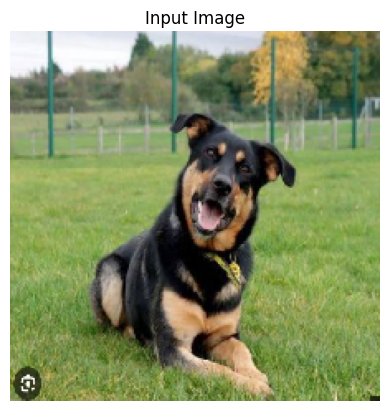

In [28]:
img = image.load_img(filename, target_size=(224, 224))

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()


In [29]:
# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Preprocess image
img_array = preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

# Get top 5 predictions
results = decode_predictions(predictions, top=5)[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [30]:
print("TOP 5 PREDICTIONS")
print("-" * 40)

for i, (_, label, probability) in enumerate(results):
    print(f"{i+1}. {label} : {probability * 100:.2f}%")


TOP 5 PREDICTIONS
----------------------------------------
1. Appenzeller : 21.56%
2. German_shepherd : 17.71%
3. Rottweiler : 15.78%
4. kelpie : 10.28%
5. Doberman : 3.74%
